<a href="https://colab.research.google.com/github/damlattlcn/Crowd-Counting-CSRNet-VGG16/blob/main/kalabal%C4%B1k_tespiti_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Drive bağlantısını yapma:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/crowd_detection

/content/drive/MyDrive/crowd_detection


In [ ]:
# Gerekli kütüphaneleri yükleme:
!pip install tensorflow
!pip install opencv-python
!pip install numpy
!pip install matplotlib
!pip install keras

!pip install torch torchvision
!pip install matplotlib
!pip install opencv-python-headless numpy matplotlib



In [ ]:

import tensorflow as tf
from tensorflow.keras.models import load_model
from keras.losses import MeanSquaredError
import pandas as pd

import os
import cv2
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error


import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import transforms
from torchvision import models

import time
import concurrent.futures
from tqdm import tqdm
import pandas as pd
import PIL
from PIL import Image
from PIL.ImageDraw import Draw
from scipy.ndimage import gaussian_filter

In [ ]:
# Kayıp fonksiyonunu bir sözlükte tanımlama
custom_objects = {'mse': MeanSquaredError()}

# Kaydedilen modeli yükleme
model_path = '/content/drive/MyDrive/crowd_detection/csrnet_model_6.h5'
model = load_model(model_path, custom_objects=custom_objects)

In [ ]:
# Görüntü işleme (örneğin Google Drive'dan bir görüntü)
image_path = '/content/drive/MyDrive/crowd_detection/frames/seq_000020.jpg'
image = cv2.imread(image_path)


In [ ]:
# Görüntüyü CSRNet modelinin girdi boyutuna göre yeniden boyutlandırma ve normalleştirme
image = cv2.resize(image, (256, 256))
image = image.astype('float32') / 255.0

In [ ]:
# Modelin beklentisi doğrultusunda şekillendirme
image = np.expand_dims(image, axis=0)  # (1, 256, 256, 3)

In [ ]:
# Model ile yoğunluk haritası tahmini yapma
predicted_density_map = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


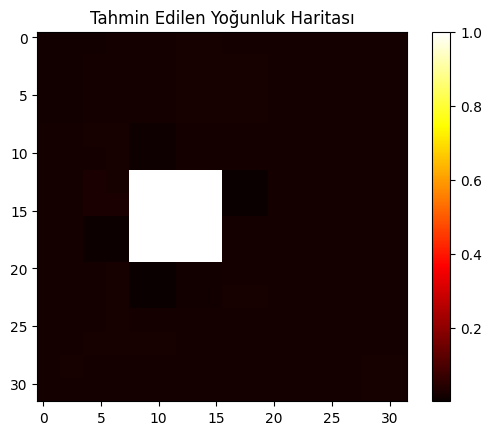

In [ ]:
# Yoğunluk haritasını görselleştirme
predicted_density_map = np.squeeze(predicted_density_map, axis=0)  # (32, 32, 1) -> (32, 32)
plt.imshow(predicted_density_map, cmap='hot')
plt.title("Tahmin Edilen Yoğunluk Haritası")
plt.colorbar()
plt.show()

In [ ]:
# Toplam kişi sayısını tahmin etme
total_people = np.sum(predicted_density_map)

# Yuvarlanmış kişi sayısı
total_people_rounded = int(np.round(total_people))

print(f"Tahmin Edilen Kişi Sayısı: {total_people_rounded}")

Tahmin Edilen Kişi Sayısı: 81


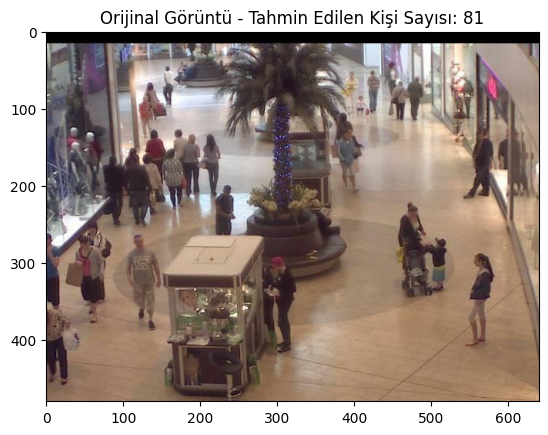

In [ ]:
original_image_path = '/content/drive/MyDrive/crowd_detection/frames/seq_000020.jpg' # Bu kısma başka bir test görseli yolu verin
original_image = cv2.imread(original_image_path)

# Orijinal görüntüyü de gösterebilirsiniz
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
plt.title(f"Orijinal Görüntü - Tahmin Edilen Kişi Sayısı: {total_people_rounded}")
plt.axis('on')
plt.show()


Model başarıyla yüklendi!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


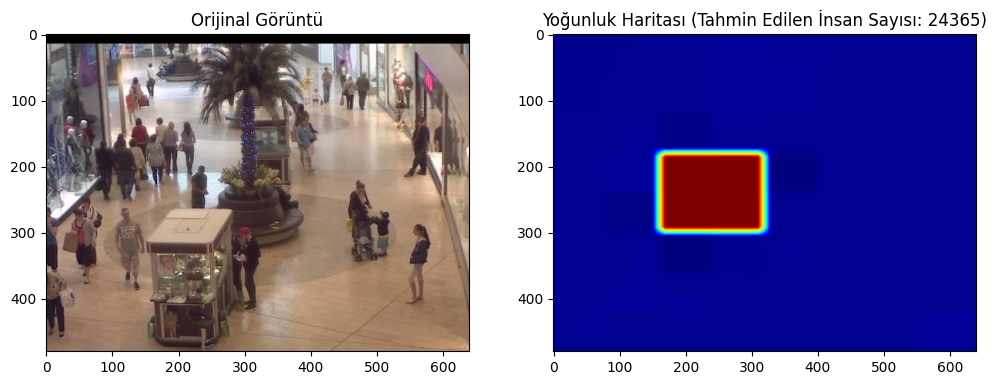

Tahmin Edilen İnsan Sayısı: 24365


In [ ]:
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import tensorflow as tf

# Özel mse fonksiyonunu yeniden tanımla
def mse(y_true, y_pred):
    return tf.keras.losses.mean_squared_error(y_true, y_pred)

# Modeli yüklerken özel kayıp fonksiyonunu belirt
model = tf.keras.models.load_model('/content/drive/MyDrive/crowd_detection/csrnet_model_6.h5', custom_objects={'mse': mse})

# Model yükleme işlemi tamam
print("Model başarıyla yüklendi!")

# Yoğunluk haritasına dayalı insan sayısını tahmin etme fonksiyonu
def predict_people_count(image_path, model):
    # Görseli yükle ve yeniden boyutlandır
    image = cv2.imread(image_path)
    image_resized = cv2.resize(image, (256, 256))

    # Modelin girdi formatına uygun hale getirme
    image_input = image_resized.astype('float32') / 255.0  # Normalleştirme
    image_input = np.expand_dims(image_input, axis=0)  # (1, 256, 256, 3) boyutuna getirme

    # Yoğunluk haritasını tahmin etme
    density_map = model.predict(image_input)[0]  # (32, 32, 1) boyutunda çıkış

    # Tahmini yoğunluk haritasını (32x32) orijinal boyutlara getirmek için ölçeklendirme
    density_map_resized = cv2.resize(density_map, (image.shape[1], image.shape[0]))

    # Yoğunluk haritasındaki değerlerin toplamı insan sayısını verir
    people_count = np.sum(density_map_resized)

    return people_count, density_map_resized

# Görselleştirme fonksiyonu
def display_results(image_path, density_map, predicted_count):
    # Orijinal görüntü
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Tahmin edilen yoğunluk haritası
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Orijinal Görüntü")

    plt.subplot(1, 2, 2)
    plt.imshow(density_map, cmap='jet')
    plt.title(f"Yoğunluk Haritası (Tahmin Edilen İnsan Sayısı: {int(predicted_count)})")

    plt.show()

# Örnek bir görselde insan sayısını tahmin etme
image_path = '/content/drive/MyDrive/crowd_detection/frames/seq_000020.jpg'  # Test görüntüsü

# Tahmini yap
predicted_count, predicted_density_map = predict_people_count(image_path, model)

# Sonuçları görselleştir
display_results(image_path, predicted_density_map, predicted_count)

print(f"Tahmin Edilen İnsan Sayısı: {int(predicted_count)}")

